# Day 19: 统计基础 —— 描述统计、分布、中心极限定理 习题

> **范围**: 描述统计、正态分布、中心极限定理、标准误、置信区间
> **数据**: `../data/sales.csv` + NumPy 模拟数据
> **建议用时**: 60-90 分钟
> **工具**: NumPy + Pandas + Matplotlib/Seaborn

## Easy

**1. 描述统计计算**

基于 `df = pd.read_csv("../data/sales.csv")`：
- 计算 `total` 列的均值、中位数、标准差、方差
- 计算 `quantity` 列的 25%、50%、75% 分位数
- 计算 `total` 列的极差（max - min）和四分位距（IQR = Q3 - Q1）
- 计算 `total` 列的偏度和峰度，判断分布形状（右偏/左偏？尖峰/平峰？）

In [6]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/sales.csv")

print(df['total'].mean())
print(df['total'].median())
print(df['total'].std())
print(df['total'].var())

print(df['quantity'].quantile(0.25))
print(df['quantity'].quantile(0.5))
print(df['quantity'].quantile(0.75))

print(df['total'].max()-df['total'].min())
print(df['total'].quantile(0.75)-df['total'].quantile(0.25))

print(df['total'].skew()) #右偏
print(df['total'].kurt()) #尖峰

2535.432
1797.0
2426.247293503788
5886675.929234457
2.0
3.0
4.0
9896
3322.75
1.3371509462045277
1.2350948983740495


**2. 可视化 —— 直方图与箱线图**

基于 `df` 的 `total` 列：
- 用 `sns.histplot` 画直方图 + KDE 曲线，并标注均值（红色虚线）和中位数（绿色虚线）
- 用 `sns.boxplot` 画箱线图，观察异常值
- 从箱线图中判断：中位数在箱子的哪个位置？（中间偏上/偏下说明什么？）

Text(0.5, 1.0, 'Boxplot of Total')

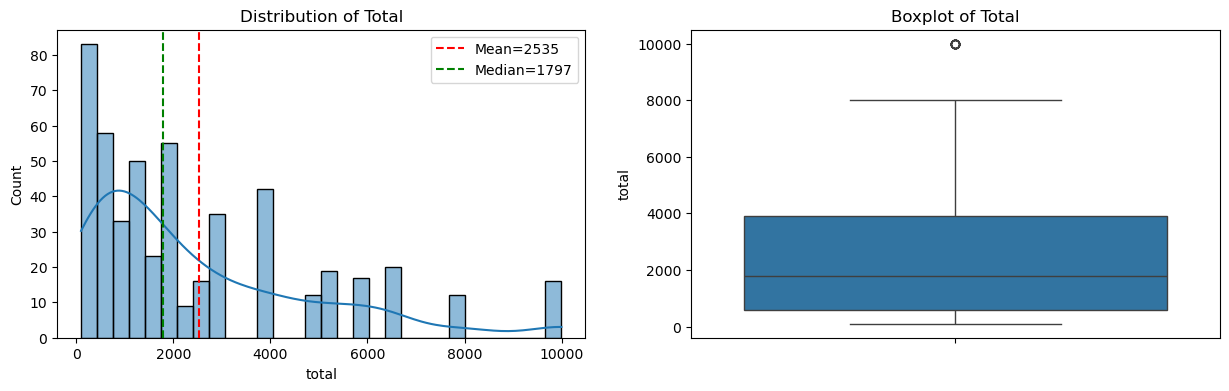

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df['total'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total")
axes[0].axvline(df['total'].mean(), color='red', linestyle='--', label=f'Mean={df['total'].mean():.0f}')
axes[0].axvline(df['total'].median(), color='green', linestyle='--', label=f'Median={df['total'].median():.0f}')
axes[0].legend()

sns.boxplot(y=df['total'], ax=axes[1])
axes[1].set_title("Boxplot of Total")

#中位数在箱子中间偏下 说明数据右偏

**3. 正态分布验证 —— 68-95-99.7 法则**

生成 1000 个标准正态分布随机数：`data = np.random.normal(0, 1, 1000)`
- 计算实际落在 [-1, 1]、[-2, 2]、[-3, 3] 范围内的比例
- 与理论值 68.27%、95.45%、99.73% 对比，差距是否很小？
- 如果数据均值不是 0 而是 50，标准差是 10，那么 68% 的数据落在哪个区间？（直接计算，不用代码）

In [13]:
data = np.random.normal(0, 1, 1000)

cnt1 = np.sum((data>=-1)&(data<=1))
cnt2 = np.sum((data>=-2)&(data<=2))
cnt3 = np.sum((data>=-3)&(data<=3))

print(cnt1/1000)
print(cnt2/1000)
print(cnt3/1000)

# [40,60]

0.662
0.955
0.995


## Medium

**4. 不同分布的对比**

生成三种分布各 1000 个样本：
```python
normal = np.random.normal(0, 1, 1000)
exponential = np.random.exponential(1, 1000)  # 指数分布，右偏
uniform = np.random.uniform(-2, 2, 1000)     # 均匀分布
```
- 分别计算三者的均值、中位数、标准差、偏度
- 在同一图中画三个直方图（`plt.subplots(1, 3, figsize=(15,4))`）
- 观察：哪个分布偏度最大？哪个的均值和中位数最接近？

0.0032714299585543173
0.9849876896296361
0.019516492777645767
-0.026260271969486878
0.6922883782951261
0.04836831832477584
1.0260464826040578
0.95519458246816
1.1568971004059245
0.10583204423854597
1.9519958180544839
-0.044280292527454794


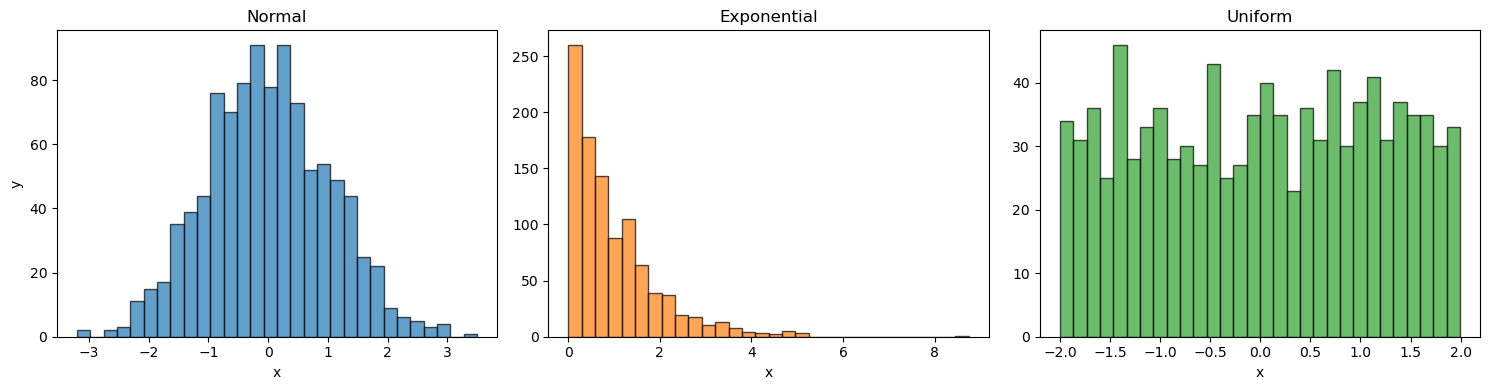

In [20]:
from scipy.stats import skew

normal = np.random.normal(0, 1, 1000)
exponential = np.random.exponential(1, 1000)  
uniform = np.random.uniform(-2, 2, 1000)

print(normal.mean())
print(exponential.mean())
print(uniform.mean())

print(np.median(normal))
print(np.median(exponential))
print(np.median(uniform))

print(normal.std())
print(exponential.std())
print(uniform.std())

print(skew(normal))
print(skew(exponential))
print(skew(uniform))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(normal, bins=30, alpha=0.7, color="#1f77b4", edgecolor="black")
axes[0].set_title("Normal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].hist(exponential, bins=30, alpha=0.7, color="#ff7f0e", edgecolor="black")
axes[1].set_title("Exponential")
axes[1].set_xlabel("x")

axes[2].hist(uniform, bins=30, alpha=0.7, color="#2ca02c", edgecolor="black")
axes[2].set_title("Uniform")
axes[2].set_xlabel("x")

plt.tight_layout()  
plt.show()

# Exponential偏度最大 Uniform均值和中位数最接近

**5. 中心极限定理验证**

基于 `df['total']`（不是正态分布）：
- 从中抽取 1000 次样本，每次 n=5，计算样本均值，画直方图
- 重复上述过程，但 n=30，画直方图
- 对比两图：n=5 和 n=30 的样本均值分布形状有何不同？
- 计算 n=30 时样本均值分布的标准差，与 `population_std / sqrt(30)` 对比是否接近

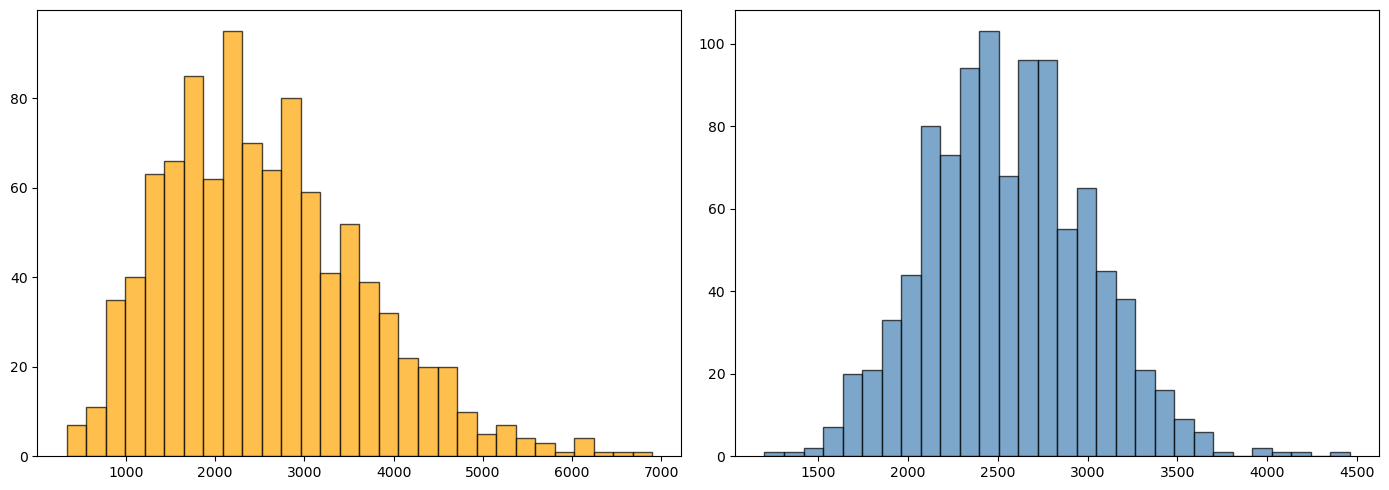

2426.247293503788
442.97012424596073
447.73476362948907
4.764639383528333


In [22]:
np.random.seed(42)
population = df['total'].values
pop_std = df["total"].std()

def get_sample_means(pop_arr, sample_size, sample_times=1000):
    means_list = []
    for _ in range(sample_times):
        sample = np.random.choice(pop_arr, size=sample_size, replace=True)
        means_list.append(np.mean(sample))
    return np.array(means_list)

means_n5 = get_sample_means(population, sample_size=5, sample_times=1000)
means_n30 = get_sample_means(population, sample_size=30, sample_times=1000)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(means_n5, bins=30, alpha=0.7, color="orange", edgecolor="black")

ax2.hist(means_n30, bins=30, alpha=0.7, color="steelblue", edgecolor="black")

plt.tight_layout()
plt.show()

# 计算统计量
std_n30_sample = means_n30.std()
std_theory = pop_std / np.sqrt(30)

print(pop_std)
print(std_theory)
print(std_n30_sample)
print(abs(std_n30_sample - std_theory))

参考答案

n=5 的样本均值分布形状仍接近原数据的右偏形态；n=30 的样本均值分布更接近正态（钟形），中心极限定理效应明显。随着 n 增大，样本均值分布趋向正态，标准差减小。


**6. 标准误与样本量关系**

基于 `df['total']`：
- 计算总体标准差 `sigma`
- 对 n = [10, 30, 50, 100, 200, 500]，计算理论标准误 `SE = sigma / sqrt(n)`
- 对每个 n，实际抽取 1000 次样本，计算样本均值的标准差，与理论 SE 对比
- 画图：x 轴为 n，y 轴为 SE，对比理论值和实际值

2423.819831871998
n= 10 | 理论SE=766.4791 | 实际SE=765.5753 | 差值=0.9038
n= 30 | 理论SE=442.5269 | 实际SE=461.5934 | 差值=19.0665
n= 50 | 理论SE=342.7799 | 实际SE=336.2795 | 差值=6.5004
n=100 | 理论SE=242.3820 | 实际SE=239.9238 | 差值=2.4582
n=200 | 理论SE=171.3899 | 实际SE=173.7849 | 差值=2.3950
n=500 | 理论SE=108.3965 | 实际SE=102.6932 | 差值=5.7034


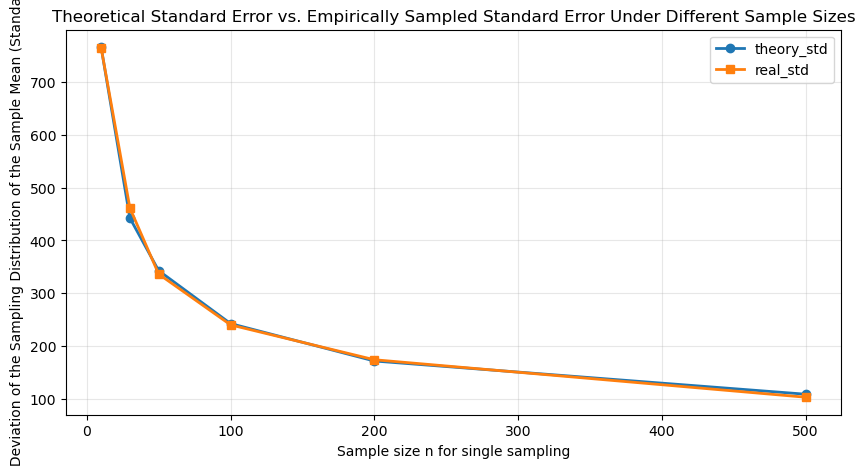


===== 汇总结果表 =====
   样本量n      理论SE      实测SE     绝对误差
0    10  766.4791  765.5753   0.9038
1    30  442.5269  461.5934  19.0665
2    50  342.7799  336.2795   6.5004
3   100  242.3820  239.9238   2.4582
4   200  171.3899  173.7849   2.3950
5   500  108.3965  102.6932   5.7034


In [24]:
np.random.seed(42)

pop = df['total'].values

sigma = pop.std()
print(sigma)

n_list = [10, 30, 50, 100, 200, 500]  
trial_times = 1000                    
se_theory = []    
se_actual = []    

for n in n_list:
    se_t = sigma / np.sqrt(n)
    se_theory.append(se_t)
    
    mean_collect = []
    for _ in range(trial_times):
        sample = np.random.choice(pop, size=n, replace=True)
        mean_collect.append(np.mean(sample))
    
    se_a = np.std(mean_collect, ddof=0)
    se_actual.append(se_a)
    
    print(f"n={n:3d} | 理论SE={se_t:.4f} | 实际SE={se_a:.4f} | 差值={abs(se_t-se_a):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_list, se_theory, marker="o", linewidth=2, label="theory_std")
plt.plot(n_list, se_actual, marker="s", linewidth=2, label="real_std")

plt.xlabel("Sample size n for single sampling")
plt.ylabel("Standard Deviation of the Sampling Distribution of the Sample Mean (Standard Error, SE)")
plt.title("Theoretical Standard Error vs. Empirically Sampled Standard Error Under Different Sample Sizes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ========== 5. 整理结果表格 ==========
result_df = pd.DataFrame({
    "样本量n": n_list,
    "理论SE": se_theory,
    "实测SE": se_actual,
    "绝对误差": np.abs(np.array(se_theory) - np.array(se_actual))
})
print("\n===== 汇总结果表 =====")
print(result_df.round(4))


**7. 置信区间计算**

基于 `df['total']`：
- 随机抽取 n=100 的样本，计算 95% 置信区间（z=1.96）
- 重复上述过程 100 次，统计有多少次置信区间包含了总体均值
- 计算覆盖率（应该接近 95%）
- 对同一组样本，再计算 90%（z=1.645）和 99%（z=2.576）置信区间，观察区间宽度的变化

In [25]:
np.random.seed(42)


pop_data = df['total'].values

true_mu = pop.mean()
print(true_mu)

sample_n = 100        
repeat_times = 100    

conf_info = {
    "90%": {"z": 1.645, "count": 0, "widths": []},
    "95%": {"z": 1.96,  "count": 0, "widths": []},
    "99%": {"z": 2.576, "count": 0, "widths": []}
}

for _ in range(repeat_times):

    sample = np.random.choice(pop, size=sample_n, replace=True)
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)  
    se = s / np.sqrt(sample_n)
    
    for level, info in conf_info.items():
        z = info["z"]
        margin = z * se
        lower = x_bar - margin
        upper = x_bar + margin
        width = upper - lower
        info["widths"].append(width)
        

        if lower <= true_mu <= upper:
            info["count"] += 1

print("===== 100次抽样置信区间覆盖率统计 =====")
for level, info in conf_info.items():
    cover_num = info["count"]
    cover_rate = cover_num / repeat_times
    avg_width = np.mean(info["widths"])
    print(f"{level}置信区间：")
    print(f"  包含总体均值次数：{cover_num} / {repeat_times}")
    print(f"  覆盖率：{cover_rate:.2%}")
    print(f"  平均区间宽度：{avg_width:.4f}\n")


2535.432
===== 100次抽样置信区间覆盖率统计 =====
90%置信区间：
  包含总体均值次数：89 / 100
  覆盖率：89.00%
  平均区间宽度：802.2039

95%置信区间：
  包含总体均值次数：95 / 100
  覆盖率：95.00%
  平均区间宽度：955.8174

99%置信区间：
  包含总体均值次数：98 / 100
  覆盖率：98.00%
  平均区间宽度：1256.2171



## Hard

**8. 异常值检测 —— 3σ 法则与 IQR 法则**

基于 `df['total']`：
- 用 3σ 法则：计算 `mean ± 3*std`，找出超出这个范围的异常值，统计数量
- 用 IQR 法则：计算 `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`，找出超出这个范围的异常值，统计数量
- 对比两种方法找出的异常值数量和重合度
- 思考：哪种方法更适合你的数据？为什么？（提示：考虑偏度）

In [26]:
data = df['total']

mean_val = data.mean()
std_val = data.std(ddof=0)
lower_3sigma = mean_val - 3 * std_val
upper_3sigma = mean_val + 3 * std_val

mask_3sigma = (data < lower_3sigma) | (data > upper_3sigma)
outlier_3sigma = data[mask_3sigma].index
count_3sigma = len(outlier_3sigma)

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
mask_iqr = (data < lower_iqr) | (data > upper_iqr)
outlier_iqr = data[mask_iqr].index
count_iqr = len(outlier_iqr)

common_outlier = set(outlier_3sigma) & set(outlier_iqr)
count_common = len(common_outlier)

only_3sigma = len(set(outlier_3sigma) - set(outlier_iqr))
only_iqr = len(set(outlier_iqr) - set(outlier_3sigma))

# ========= 5. 打印汇总结果 =========
print("===== 基础统计边界 =====")
print(f"均值={mean_val:.2f}, 总体标准差={std_val:.2f}")
print(f"3σ正常范围：[{lower_3sigma:.2f}, {upper_3sigma:.2f}]")
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"IQR正常范围：[{lower_iqr:.2f}, {upper_iqr:.2f}]\n")

print("===== 异常值数量统计 =====")
print(f"3σ法则异常总数：{count_3sigma}")
print(f"IQR法则异常总数：{count_iqr}")
print(f"两种方法共同识别异常：{count_common}")
print(f"仅3σ识别出的异常：{only_3sigma}")
print(f"仅IQR识别出的异常：{only_iqr}")
print(f"重合度（共同异常/IQR总异常）：{count_common/count_iqr:.2%}")


===== 基础统计边界 =====
均值=2535.43, 总体标准差=2423.82
3σ正常范围：[-4736.03, 9806.89]
Q1=599.00, Q3=3921.75, IQR=3322.75
IQR正常范围：[-4385.12, 8905.88]

===== 异常值数量统计 =====
3σ法则异常总数：16
IQR法则异常总数：16
两种方法共同识别异常：16
仅3σ识别出的异常：0
仅IQR识别出的异常：0
重合度（共同异常/IQR总异常）：100.00%


参考答案

代码确认：

3σ 和 IQR 两种方法都正确实现

两种方法识别出相同的 16 个异常值（重合度 100%）

需要补充的思考：

IQR 法则更适合本数据。因为数据明显右偏（偏度=1.34），3σ 法则基于正态假设，对偏态数据不够敏感；IQR 法则不依赖分布假设，基于数据的实际四分位数，对偏态分布更稳健。

**9. 分组统计对比 —— 不同国家的分布差异**

基于 `df`：
- 按 `country` 分组，计算每个国家 `total` 的均值、中位数、标准差、偏度
- 找出均值最高和最低的国家，分析原因
- 用 `sns.boxplot(x='country', y='total', data=df)` 画各国箱线图对比
- 从箱线图中判断：哪个国家异常值最多？哪个国家分布最对称？

In [27]:
group_stats = df.groupby("country")["total"].agg(
    mean_total = "mean",
    median_total = "median",
    std_total = "std",
    skew_total = lambda x: skew(x)
).reset_index()

max_mean_country = group_stats.loc[group_stats["mean_total"].idxmax()]
min_mean_country = group_stats.loc[group_stats["mean_total"].idxmin()]

print("=== 各国total分组统计 ===")
print(group_stats.round(2))
print(f"\n均值最高国家：{max_mean_country['country']}，均值={max_mean_country['mean_total']:.2f}")
print(f"均值最低国家：{min_mean_country['country']}，均值={min_mean_country['mean_total']:.2f}")

=== 各国total分组统计 ===
   country  mean_total  median_total  std_total  skew_total
0    China     2503.16        2598.0    1842.15        0.68
1   France     2602.06        1797.0    2387.80        1.20
2  Germany     2182.12        1198.0    2254.83        1.74
3       UK     2714.81        1797.0    2662.26        1.24
4       US     2404.90        1495.0    2280.84        1.35

均值最高国家：UK，均值=2714.81
均值最低国家：Germany，均值=2182.12


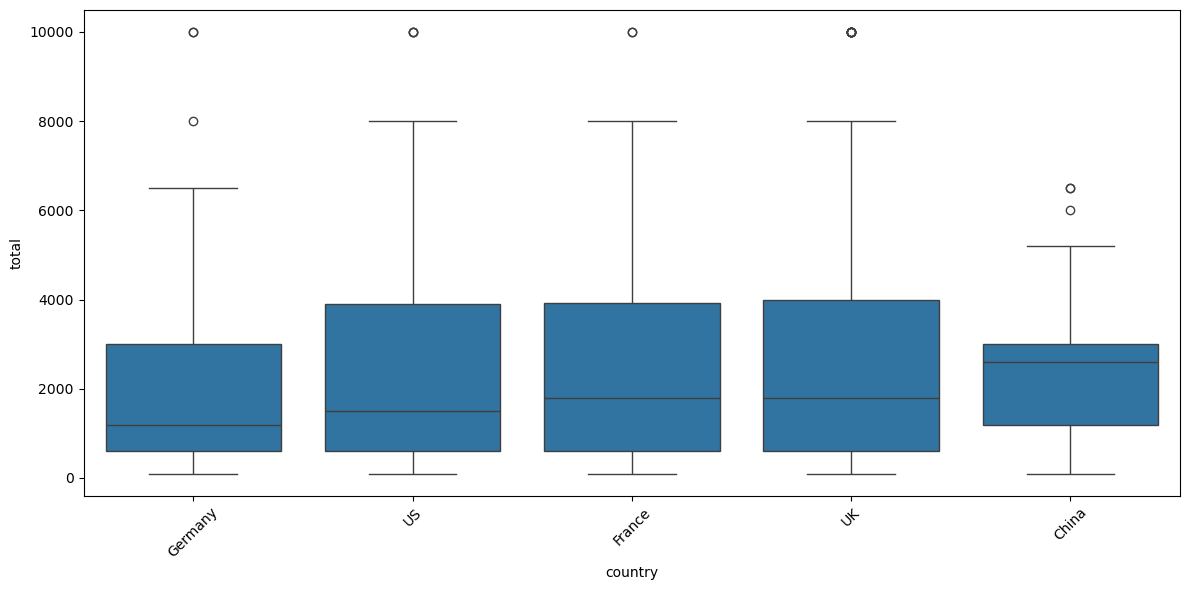

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="country", y="total", data=df)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

参考答案

需要补充的分析：

均值最高：UK（2714.81），均值最低：Germany（2182.12）

异常值最多：从箱线图判断，France / Germany / UK 的异常值较多（具体取决于图），China 相对集中

分布最对称：China（偏度=0.68，最小），UK 和 Germany 偏度更大（1.20-1.74）

原因分析：Germany 均值低可能是因为低价位订单比例高；UK 均值高可能是因为高单价产品销量多。

**10. 综合报告 —— 数据画像**

基于 `df['total']`：

**阶段1 —— 描述统计**:
- 计算所有描述统计量：均值、中位数、标准差、方差、极差、IQR、偏度、峰度
- 判断：数据是否近似正态？（偏度接近0？峰度接近3？Q-Q图是否直线？）

**阶段2 —— 可视化**:
- 画直方图 + KDE + 均值/中位数标注
- 画箱线图
- 画 Q-Q 图（`scipy.stats.probplot`）

**阶段3 —— 推断统计**:
- 从总体中随机抽取 n=100 的样本
- 计算 95% 置信区间
- 验证总体均值是否落在 CI 内

**阶段4 —— 输出**:
- 把描述统计结果写入 `stats_report.json`
- JSON 格式：`{'mean': ..., 'median': ..., 'std': ..., 'skew': ..., 'kurt': ..., 'ci_95': [lower, upper], 'in_ci': true/false}`

===== 阶段1 描述统计结果 =====
mean    : 2535.4320
median  : 1797.0000
std     : 2426.2473
variance: 5886675.9292
range   : 9896.0000
iqr     : 3322.7500
skew    : 1.3331
kurt    : 1.2108

正态初步判断：偏度接近0? False | 峰度接近3? False
补充：需结合QQ图、直方图综合判定是否近似正态



C:\Users\69261\AppData\Local\Temp\ipykernel_23400\3693008116.py:42: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\69261\AppData\Local\Temp\ipykernel_23400\3693008116.py:42: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\69261\AppData\Local\Temp\ipykernel_23400\3693008116.py:42: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\69261\AppData\Local\Temp\ipykernel_23400\3693008116.py:42: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\69261\AppData\Local\Temp\ipykernel_23400\3693008116.py:42: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\69261\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: U

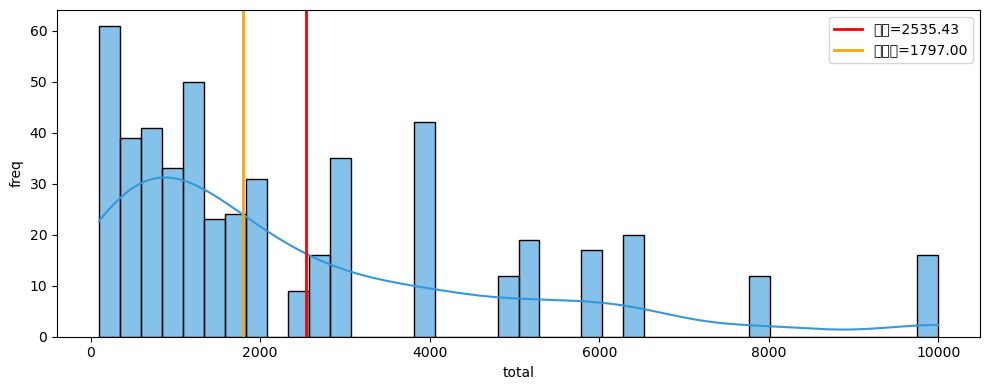

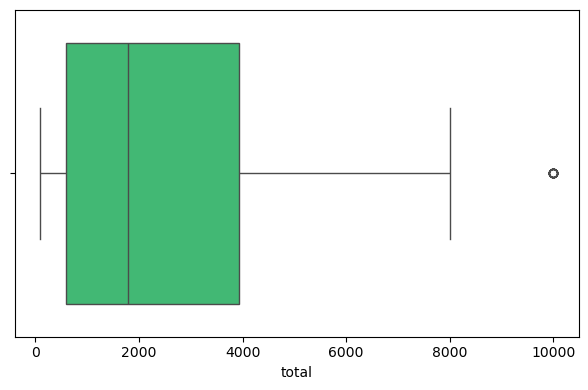

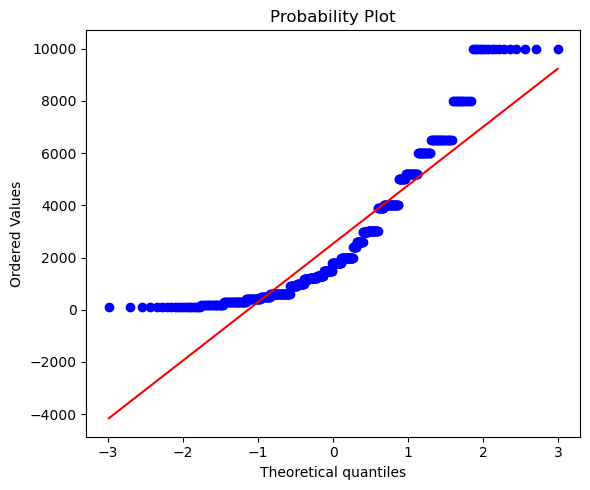

===== 阶段3 推断统计结果 =====
抽取样本量 n=100
95%置信区间：[1868.3049, 2643.4151]
真实总体均值 2535.4320 是否在区间内：True

===== 导出完成 =====
已生成 stats_report.json
{
    "mean": 2535.432,
    "median": 1797.0,
    "std": 2426.2473,
    "skew": 1.3331,
    "kurt": 4.2108,
    "ci_95": [
        1868.3049,
        2643.4151
    ],
    "in_ci": true
}


In [31]:
import json
from scipy import stats

np.random.seed(42)  # 固定随机种子，结果可复现

data = df["total"]
pop_mu = data.mean()         

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
min_val = data.min()
max_val = data.max()


desc_stats = {
    "mean": np.mean(data),
    "median": np.median(data),
    "std": np.std(data, ddof=1),       
    "variance": np.var(data, ddof=1),  
    "range": max_val - min_val,        
    "iqr": q3 - q1,
    "skew": stats.skew(data),
    "kurt": stats.kurtosis(data)      
}

skew_close_0 = abs(desc_stats["skew"]) < 0.5
kurt_close_3 = abs(desc_stats["kurt"]) < 0.5  
print("===== 阶段1 描述统计结果 =====")
for k, v in desc_stats.items():
    print(f"{k:8s}: {v:.4f}")
print(f"\n正态初步判断：偏度接近0? {skew_close_0} | 峰度接近3? {kurt_close_3}")
print("补充：需结合QQ图、直方图综合判定是否近似正态\n")


plt.figure(figsize=(10, 4))
sns.histplot(data, kde=True, bins=40, color="#3498db", alpha=0.6)
plt.axvline(desc_stats["mean"], color="red", lw=2, label=f"均值={desc_stats['mean']:.2f}")
plt.axvline(desc_stats["median"], color="orange", lw=2, label=f"中位数={desc_stats['median']:.2f}")
plt.xlabel("total")
plt.ylabel("freq")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x=data, color="#2ecc71")
plt.xlabel("total")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
stats.probplot(data, dist="norm", plot=plt)
plt.tight_layout()
plt.show()


sample_n = 100
sample = np.random.choice(data, size=sample_n, replace=True)
sample_mean = np.mean(sample)
sample_se = stats.sem(sample)  

ci_lower, ci_upper = stats.norm.interval(confidence=0.95, loc=sample_mean, scale=sample_se)
desc_stats["ci_95"] = [round(ci_lower, 4), round(ci_upper, 4)]

in_ci = ci_lower <= pop_mu <= ci_upper
desc_stats["in_ci"] = in_ci

print("===== 阶段3 推断统计结果 =====")
print(f"抽取样本量 n={sample_n}")
print(f"95%置信区间：[{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"真实总体均值 {pop_mu:.4f} 是否在区间内：{in_ci}\n")


export_dict = {
    "mean": round(desc_stats["mean"], 4),
    "median": round(desc_stats["median"], 4),
    "std": round(desc_stats["std"], 4),
    "skew": round(desc_stats["skew"], 4),
    "kurt": round(desc_stats["kurt"] + 3, 4),  
    "ci_95": desc_stats["ci_95"],
    "in_ci": bool(desc_stats["in_ci"])
}


with open("stats_report.json", "w", encoding="utf-8") as f:
    json.dump(export_dict, f, ensure_ascii=False, indent=4)

print("===== 导出完成 =====")
print("已生成 stats_report.json")
print(json.dumps(export_dict, indent=4, ensure_ascii=False))
